[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tashraf-745/Advanced_Data_Analysis_ML/blob/main/Project_1.ipynb)

# **Project 1**

This project uses 311 service request dataset that tracks complaints from NYC residents.
The purpose of this project is to divide the dataset into a training set and a testing set, explortion of the training set, data cleaning, visualizing the training data, and applying transformations to the data.

## Import libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from six.moves import urllib

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

## Mount Drive and File Paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Creating folder path to store all data files
DRIVE_PATH = '/content/drive/MyDrive/Advanced_Data_Analysis/data'
os.makedirs(DRIVE_PATH, exist_ok=True)

# Creating file paths for different datasets to be stored
RAW_PATH = os.path.join(DRIVE_PATH, 'nyc311_raw_2022_2023.csv')
TRAIN_CLEAN_PATH = os.path.join(DRIVE_PATH, 'nyc311_train_clean.csv')
TEST_CLEAN_PATH = os.path.join(DRIVE_PATH, 'nyc311_test_clean.csv')

print(f'RAW_PATH: {RAW_PATH}')
print(f'TRAIN_CLEAN_PATH: {TRAIN_CLEAN_PATH}')
print(f'TEST_CLEAN_PATH: {TEST_CLEAN_PATH}')

Mounted at /content/drive
RAW_PATH: /content/drive/MyDrive/Advanced_Data_Analysis/data/nyc311_raw_2022_2023.csv
TRAIN_CLEAN_PATH: /content/drive/MyDrive/Advanced_Data_Analysis/data/nyc311_train_clean.csv
TEST_CLEAN_PATH: /content/drive/MyDrive/Advanced_Data_Analysis/data/nyc311_test_clean.csv


## Step 1: Download Dataset

In [ ]:
DOWNLOAD_ROOT = 'https://data.cityofnewyork.us/resource/erm2-nwe9.csv'
BATCH_LIMIT = 50000
DATE_FILTER = ("created_date >= '2022-01-01T00:00:00'" " AND created_date < '2024-01-01T00:00:00'")

print(f'DOWNLOAD_ROOT: {DOWNLOAD_ROOT}')
print(f'DATE_FILTER: {DATE_FILTER}')
print(f'BATCH_LIMIT: {BATCH_LIMIT:,} rows per page')

DOWNLOAD_ROOT: https://data.cityofnewyork.us/resource/erm2-nwe9.csv
DATE_FILTER: created_date >= '2022-01-01T00:00:00' AND created_date < '2024-01-01T00:00:00'
BATCH_LIMIT: 50,000 rows per page


In [ ]:
# Saving data to RAW_PATH
def fetch_nyc311_data(raw_path=RAW_PATH):
    if os.path.isfile(raw_path):
        return
    urllib.request.urlretrieve(DOWNLOAD_ROOT + '?' + urllib.parse.urlencode({'$limit': BATCH_LIMIT, '$where': DATE_FILTER, '$order': 'unique_key'}), raw_path)
    print(f'Download complete: {raw_path}')

In [ ]:
fetch_nyc311_data()

In [ ]:
# Loading data
def load_nyc311_data(raw_path=RAW_PATH):
    return pd.read_csv(raw_path, dtype={'unique_key': str, 'incident_zip': str, 'community_board': str}, na_values=['N/A', 'n/a', '', ' '], parse_dates=['created_date', 'closed_date'])

df_raw = load_nyc311_data()
df_raw.head()

/tmp/ipykernel_3915/2853951549.py:3: DtypeWarning: Columns (34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(raw_path, dtype={'unique_key': str, 'incident_zip': str, 'community_board': str}, na_values=['N/A', 'n/a', '', ' '], parse_dates=['created_date', 'closed_date'])


,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,descriptor_2,location_type,incident_zip,...,vehicle_type,taxi_company_borough,taxi_pick_up_location,bridge_highway_name,bridge_highway_direction,road_ramp,bridge_highway_segment,latitude,longitude,location
0,52931529,2022-01-01 01:56:24,2022-01-01 02:00:36,NYPD,New York City Police Department,Noise - Vehicle,Engine Idling,NaN,Street/Sidewalk,10034,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.866759,-73.930915,POINT (-73.93091510012 40.866759390133)
1,52931568,2022-01-01 01:13:49,2022-01-01 05:20:07,NYPD,New York City Police Department,Blocked Driveway,No Access,NaN,Street/Sidewalk,10461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.836924,-73.829880,POINT (-73.829880371547 40.83692398445)
2,52931587,2022-01-01 01:40:28,2022-01-01 01:43:31,NYPD,New York City Police Department,Blocked Driveway,Partial Access,NaN,Street/Sidewalk,11239,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.655336,-73.871927,POINT (-73.871926877539 40.655336208354)
3,52931588,2022-01-01 00:57:13,2022-01-01 00:58:36,NYPD,New York City Police Department,Blocked Driveway,Partial Access,NaN,Street/Sidewalk,11239,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.655336,-73.871927,POINT (-73.871926877539 40.655336208354)
4,52931607,2022-01-01 01:16:11,2022-01-01 09:19:51,NYPD,New York City Police Department,Blocked Driveway,Partial Access,NaN,Street/Sidewalk,11356,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.790771,-73.843425,POINT (-73.843425397924 40.7907714015)


## Data Preparation

Preparing target variable `closed_within_7_days` to balance split.

Computing response times, creating a binary target variable, and filtering only closed cases.

49,458 rows qualified for modeling. 82.2% closed within 7 days (class 1) and 17.8% took longer (class 0).

In [ ]:
df = df_raw.copy()
# Parsing dates to compute response time
df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
df['closed_date']  = pd.to_datetime(df['closed_date'],  errors='coerce')

# Response time in hours
raw_rt = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600
df['response_time_hours'] = np.where(raw_rt.notna(), np.maximum(raw_rt.fillna(0), 0), np.nan)

# Target variable
closed_mask = (df['status'] == 'Closed') & df['response_time_hours'].notna()
df['closed_within_7_days'] = np.nan
df.loc[closed_mask, 'closed_within_7_days'] = (df.loc[closed_mask, 'response_time_hours'] <= 168).astype(int)
df_ml = df[closed_mask].copy()
df_ml['closed_within_7_days'] = df_ml['closed_within_7_days'].astype(int)

print(f'ML-ready rows: {len(df_ml):,}')
print(df_ml['closed_within_7_days'].value_counts(normalize=True).mul(100).round(1)
      .rename({1: '1 — closed ≤7 days', 0: '0 — closed >7 days'}))

ML-ready rows: 49,458
closed_within_7_days
1 — closed ≤7 days    82.2
0 — closed >7 days    17.8
Name: proportion, dtype: float64


## Step 2: Train/Test Split

`StratifiedShuffleSplit` divided the 49,458 closed rows into 39,566 for training and 9,892 for testing (80/20). Stratifying on `closed_within_7_days` so both sets land at exactly 82.18% fast resolutions and 17.82% slow ones.

In [ ]:
TARGET = 'closed_within_7_days'

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(df_ml, df_ml[TARGET]):
    df_train = df_ml.iloc[train_index].copy()
    df_test = df_ml.iloc[test_index].copy()

print(f'Training: {df_train.shape[0]:,} rows × {df_train.shape[1]} columns')
print(f'Testing: {df_test.shape[0]:,} rows × {df_test.shape[1]} columns')
print('\nTarget balance: training:')
print(df_train[TARGET].value_counts(normalize=True).mul(100).round(2))
print('\nTarget balance: testing:')
print(df_test[TARGET].value_counts(normalize=True).mul(100).round(2))

Training: 39,566 rows × 46 columns
Testing: 9,892 rows × 46 columns

Target balance: training:
closed_within_7_days
1    82.18
0    17.82
Name: proportion, dtype: float64

Target balance: testing:
closed_within_7_days
1    82.18
0    17.82
Name: proportion, dtype: float64


## Step 3: Training Set Exploration

The training set has 39,566 rows and 46 columns. Several columns are entirely empty and a few have missing values. The two key columns, `response_time_hours` and `closed_within_7_days`, are fully non-null. Of the 46 columns, 36 are object (string) type and either get one-hot encoded or dropped before modeling.


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39566 entries, 43872 to 18028
Data columns (total 46 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   unique_key                      39566 non-null  object        
 1   created_date                    39566 non-null  datetime64[ns]
 2   closed_date                     39566 non-null  datetime64[ns]
 3   agency                          39566 non-null  object        
 4   agency_name                     39566 non-null  object        
 5   complaint_type                  39566 non-null  object        
 6   descriptor                      38470 non-null  object        
 7   descriptor_2                    16925 non-null  object        
 8   location_type                   35481 non-null  object        
 9   incident_zip                    38997 non-null  object        
 10  incident_address                37902 non-null  object        
 11  str

`response_time_hours` has a median of ~25 hours and a mean of ~628 hours, with a maximum of 33,531 hours (nearly 4 years). A small number of extreme cases, complaints left open for months or longer, pull the mean far above what most requests actually experience.

In [ ]:
df_train.describe()

,created_date,closed_date,council_district,bbl,x_coordinate_state_plane,y_coordinate_state_plane,latitude,longitude,response_time_hours,closed_within_7_days
count,39566,39566,38779.000000,3.602100e+04,3.916400e+04,39168.000000,39164.000000,39164.000000,39566.000000,39566.000000
mean,2022-01-04 09:09:41.650634496,2022-01-30 13:06:32.774402304,24.886537,2.751085e+09,1.005178e+06,206759.349188,40.734128,-73.924445,627.947707,0.821817
min,2022-01-01 00:00:00,2022-01-01 00:03:04,1.000000,0.000000e+00,9.138310e+05,121204.000000,40.499093,-74.253236,0.000000,0.000000
25%,2022-01-02 23:29:28.500000,2022-01-04 01:17:31.500000,12.000000,2.027990e+09,9.933308e+05,183356.500000,40.669892,-73.967285,0.983681,1.000000
50%,2022-01-04 11:21:07.500000,2022-01-06 00:52:48.500000,24.000000,3.019760e+09,1.004421e+06,204352.000000,40.727516,-73.927183,24.744722,1.000000
75%,2022-01-05 18:04:00.750000128,2022-01-09 12:49:14.750000128,37.000000,4.011300e+09,1.018026e+06,235969.750000,40.814341,-73.878047,101.316042,1.000000
max,2022-01-08 01:55:27,2025-10-30 13:51:46,51.000000,5.200040e+09,1.066919e+06,271621.000000,40.912168,-73.701639,33531.646111,1.000000
std,NaN,NaN,14.548652,1.183090e+09,2.227540e+04,31838.034396,0.087394,0.080330,3127.099818,0.382672


## Step 4: Data Cleaning



Cleaning the raw training data and then applying the same transformations to the test set through engineer_features() function.

Dropped two types of columns: near empty and the ones that cause data leakage.

Removed rows with unrecognized boroughs and null out any `closed_date` falling before `created_date`.

Created features the model will learn from : `created_hour`, `created_dayofweek`, `created_month`, `is_weekend`, and `is_business_hours`, which identifies when the complaint was filed. `cb_number` identifies the community board geography and `channel_online` identifies whether the complaint came through the web portal.

In [ ]:
COLS_TO_DROP = ['vehicle_type', 'taxi_company_borough', 'road_ramp', 'due_date',
'bridge_highway_direction', 'facility_type', 'taxi_pick_up_location',
'bridge_highway_segment', 'bridge_highway_name', 'landmark',
'intersection_street_1', 'intersection_street_2',
'cross_street_1', 'cross_street_2', 'park_facility_name', 'park_borough',
'city', 'bbl', 'resolution_description', 'resolution_action_updated_date',
'location', 'x_coordinate_state_plane', 'y_coordinate_state_plane',]

VALID_BOROUGHS = ['BRONX', 'BROOKLYN', 'MANHATTAN', 'QUEENS', 'STATEN ISLAND']

ML_COLS = ['created_hour', 'created_dayofweek', 'created_month',
'is_weekend', 'is_business_hours', 'channel_online',
'cb_number', 'response_time_hours','borough', 'open_data_channel_type', TARGET,]

In [ ]:
def engineer_features(df):
    df = df.copy()
    df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)
    df = df[df['borough'].isin(VALID_BOROUGHS)].copy()
    neg_mask = df['closed_date'] < df['created_date']
    df.loc[neg_mask, 'closed_date'] = np.nan
    mis_mask = (df['status'] != 'Closed') & df['closed_date'].notna()
    df.loc[mis_mask, 'closed_date'] = np.nan
    df['cb_number'] = df['community_board'].astype(str).str.extract(r'^(\d+)', expand=False).astype(float)
    df['created_hour'] = df['created_date'].dt.hour
    df['created_dayofweek'] = df['created_date'].dt.dayofweek
    df['created_month'] = df['created_date'].dt.month
    df['is_weekend'] = (df['created_dayofweek'] >= 5).astype(int)
    df['is_business_hours'] = ((df['created_dayofweek'] < 5) & (df['created_hour'] >= 9) & (df['created_hour'] < 17)).astype(int)
    df['channel_online'] = (df['open_data_channel_type'] == 'ONLINE').astype(int)
    return df[[c for c in ML_COLS if c in df.columns]]

df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)

print(f'Train after feature engineering: {df_train.shape}')
print(f'Test after feature engineering:  {df_test.shape}')
print(f'\nColumns: {list(df_train.columns)}')

Train after feature engineering: (39530, 11)
Test after feature engineering:  (9885, 11)

Columns: ['created_hour', 'created_dayofweek', 'created_month', 'is_weekend', 'is_business_hours', 'channel_online', 'cb_number', 'response_time_hours', 'borough', 'open_data_channel_type', 'closed_within_7_days']


Inspecting each column in the training dataset to identify exactly which features contain missing values.

In [ ]:
# Checking missing values
for col in df_train.columns:
    has_null = df_train[col].isnull().values.any()
    if has_null:
        n_null = df_train[col].isnull().values.sum()
        print(f'  {col:}: isnull, count = {n_null:,}')

  cb_number: isnull, count = 622


Using SimpleImputer to fill in the missing values.

`strategy='median'` would help with the extreme outliers in response_time_hours.

In [ ]:
NUMERIC_COLS = ['created_hour', 'created_dayofweek', 'created_month',
                'is_weekend', 'is_business_hours', 'channel_online',
                'cb_number', 'response_time_hours']

df_train_clean = df_train.copy()
df_test_clean = df_test.copy()

# Fit only on training data
imp_median = SimpleImputer(missing_values=np.nan, strategy='median')
imp_median.fit(df_train_clean[NUMERIC_COLS])

print('SimpleImputer fitted on training set:')
for col, stat in zip(NUMERIC_COLS, imp_median.statistics_):
    print(f'  {col:} median = {stat:.4f}')

# Transform both sets
df_train_clean[NUMERIC_COLS] = imp_median.transform(df_train_clean[NUMERIC_COLS])
df_test_clean[NUMERIC_COLS] = imp_median.transform(df_test_clean[NUMERIC_COLS])

# Categorical nulls
for col in ['borough', 'open_data_channel_type']:
    if col in df_train_clean.columns:
        mode_val = df_train_clean[col].mode()[0]
        df_train_clean[col] = df_train_clean[col].fillna(mode_val)
        df_test_clean[col] = df_test_clean[col].fillna(mode_val)

print(f'\nRemaining nulls: training : {df_train_clean.isnull().sum().sum():,}')
print(f'Remaining nulls: testing  : {df_test_clean.isnull().sum().sum():,}')

SimpleImputer fitted on training set:
  created_hour median = 13.0000
  created_dayofweek median = 2.0000
  created_month median = 1.0000
  is_weekend median = 0.0000
  is_business_hours median = 0.0000
  channel_online median = 0.0000
  cb_number median = 7.0000
  response_time_hours median = 24.7554

Remaining nulls: training : 0
Remaining nulls: testing  : 0


`pd.get_dummies` converted the string columns into numeric binary columns so that scikit-learn models can use them.

In [ ]:
print("Original features:\n", list(df_train_clean.columns))

# pd.get_dummies perform one-hot encoding
df_train_dummies = pd.get_dummies(df_train_clean)
df_test_dummies = pd.get_dummies(df_test_clean)

# Align columns to ensure both datasets contain exactly the same columns
df_train_dummies, df_test_dummies = df_train_dummies.align(
    df_test_dummies, join='left', axis=1, fill_value=0)

print("\nFeatures after get_dummies:\n", list(df_train_dummies.columns))

# Separate predictors from the target variable
feature_cols = [c for c in df_train_dummies.columns if c != TARGET]
X_train = df_train_dummies[feature_cols].values
y_train = df_train_dummies[TARGET].values
X_test = df_test_dummies[feature_cols].values
y_test = df_test_dummies[TARGET].values

print(f'\nX_train.shape: {X_train.shape} y_train.shape: {y_train.shape}')
print(f'X_test.shape: {X_test.shape} y_test.shape: {y_test.shape}')

Original features:
 ['created_hour', 'created_dayofweek', 'created_month', 'is_weekend', 'is_business_hours', 'channel_online', 'cb_number', 'response_time_hours', 'borough', 'open_data_channel_type', 'closed_within_7_days']

Features after get_dummies:
 ['created_hour', 'created_dayofweek', 'created_month', 'is_weekend', 'is_business_hours', 'channel_online', 'cb_number', 'response_time_hours', 'closed_within_7_days', 'borough_BRONX', 'borough_BROOKLYN', 'borough_MANHATTAN', 'borough_QUEENS', 'borough_STATEN ISLAND', 'open_data_channel_type_MOBILE', 'open_data_channel_type_ONLINE', 'open_data_channel_type_PHONE', 'open_data_channel_type_UNKNOWN']

X_train.shape: (39530, 17) y_train.shape: (39530,)
X_test.shape: (9885, 17) y_test.shape: (9885,)


In [ ]:
# Save cleaned datasets
df_train_clean.to_csv(TRAIN_CLEAN_PATH, index=False)
df_test_clean.to_csv(TEST_CLEAN_PATH,   index=False)

## Step 5: Visualize the Training set data

The histograms show the distribution of every feature in the cleaned training set. `created_hour` peaks between 10 AM and 6 PM, showing most complaints arrive during these hours. `created_dayofweek` highlight Monday through Thursday (0-3) as the busiest days, with a sharp drop on Friday and a smaller weekend bump.

`cb_number` skews right, with most complaints concentrated in lower-numbered community boards (1-20), reflecting population density in central Manhattan and Brooklyn. `response_time_hours` skews heavily right. The vast majority of complaints resolve within a few hundred hours, but a small tail stretches to 35,000 hours.

`closed_within_7_days` shows imbalance: the bar at 1 is taller than the bar at 0, putting about 82% of complaints in the fast resolution class.



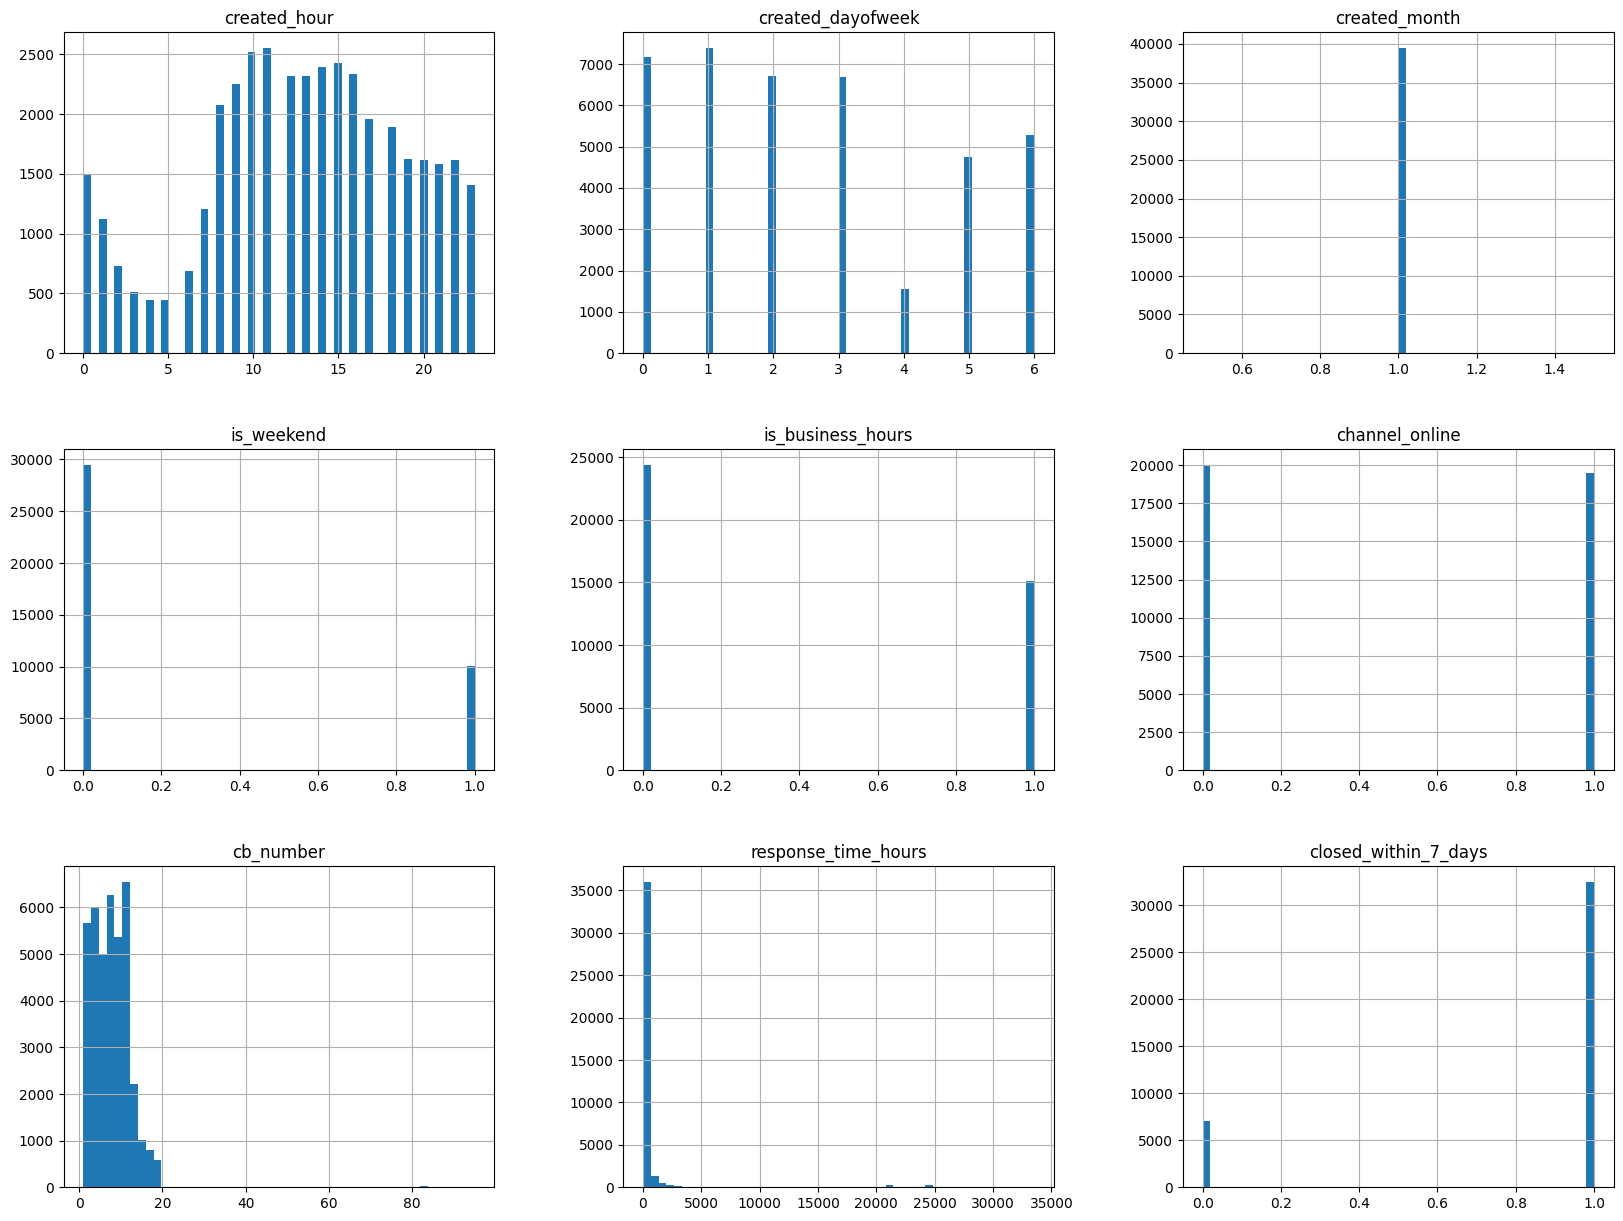

In [ ]:
# Histogram
df_train_clean.hist(bins=50, figsize=(20, 15))
plt.show()

The scatter matrix shows relationships between five key variables. The most useful is `response_time_hours` against `closed_within_7_days`: complaints with short response times cluster at 1 while outliers stretching past 30,000 hours all sit at 0, making response time the strongest visual predictor of whether a complaint closes within a week.



/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(boundaries_list[i])


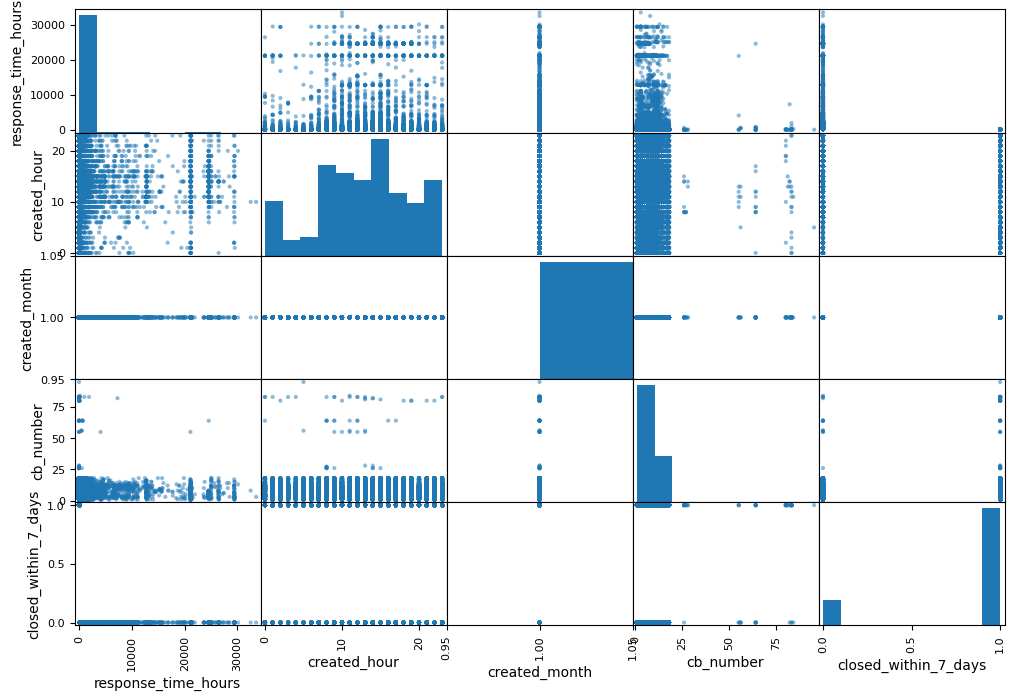

In [ ]:
# Scatter Plot
attributes = ['response_time_hours', 'created_hour',
              'created_month', 'cb_number', 'closed_within_7_days']

scatter_matrix(df_train_clean[attributes], figsize=(12, 8))
plt.show()

The correlation matrix measures how strongly each numeric feature relates with `closed_within_7_days`. `response_time_hours` has the strongest relationship at -0.41, longer response times mean the complaint was not closed within 7 days. `is_business_hours` comes in at -0.15, meaning complaints filed during business hours take longer on average. `is_weekend` and `created_dayofweek` are weakly positive (0.06-0.08), suggesting weekend complaints close slightly faster when fewer incoming complaints keep the queue shorter.

In [ ]:
# Correlation Matrix
numeric_only = df_train_clean.select_dtypes(include=[np.number])

corr_matrix = numeric_only.corr()

# Sort by correlation with target
print('Correlation with closed_within_7_days:')
print(corr_matrix['closed_within_7_days'].sort_values(ascending=False))

Correlation with closed_within_7_days:
closed_within_7_days    1.000000
is_weekend              0.084254
created_dayofweek       0.062307
channel_online          0.052361
cb_number              -0.006023
created_hour           -0.035456
is_business_hours      -0.152855
response_time_hours    -0.410397
created_month                NaN
Name: closed_within_7_days, dtype: float64


## Step 6: Data Transformation

The five histograms show four transformations to `response_time_hours` to show how each one reshapes the original distribution.

The original is heavily right skewed: the vast majority of complaints resolve within 100 hours, but a small tail stretches to 720+ hours.

Squaring and cubing, applied to the normalised values, amplified the imbalance by pushing almost everything near zero while outliers stacked at 1.0.

The log transform spreads the distribution across a wider range, revealing two peaks, one for complaints resolved in about an hour and another for those taking a few days.

The exponential transform stays right skewed because compressing the normalised values produced a shape similar to the original.

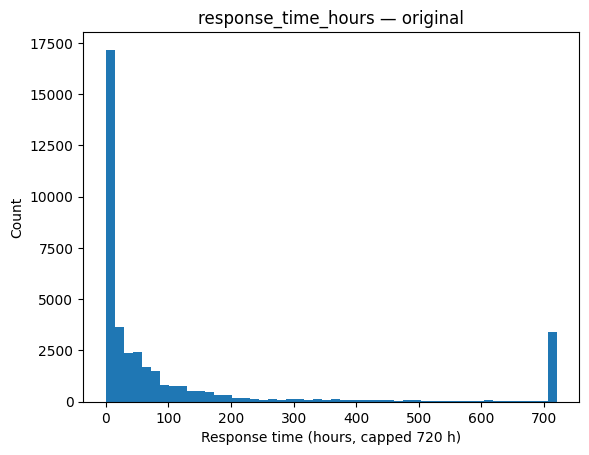

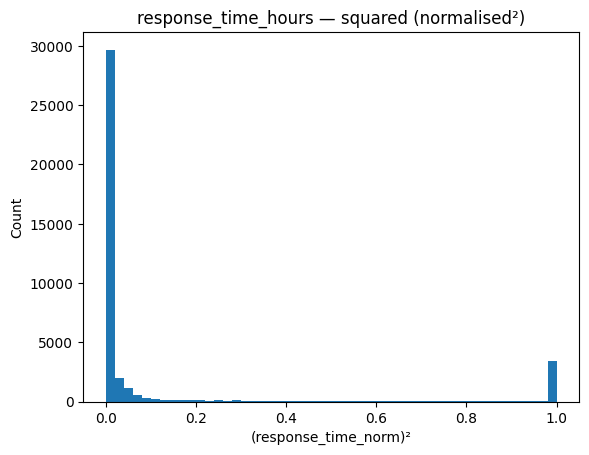

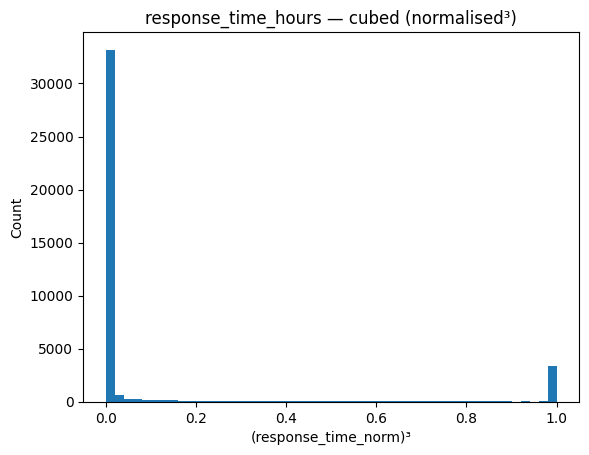

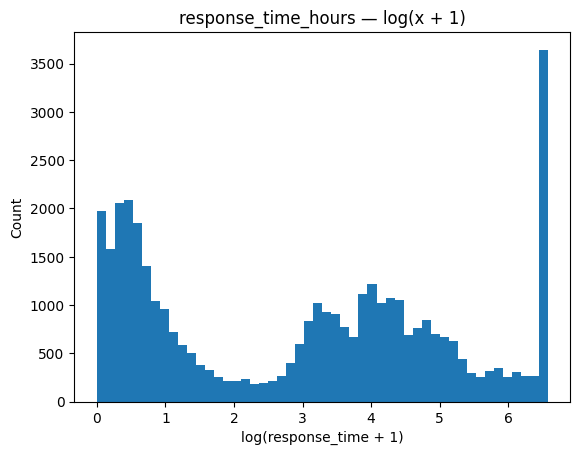

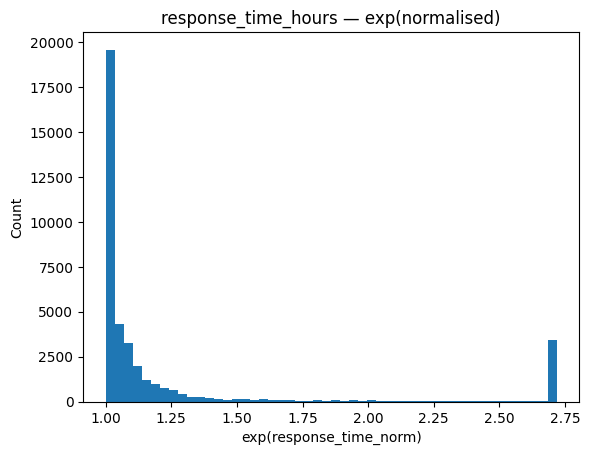

In [ ]:
# Feature 1: response_time_hours

nbins = 50
rt = df_train_clean['response_time_hours'].clip(upper=720).dropna().values

# Normalise to [0, 1] to prevent overflow
rt_min, rt_max = rt.min(), rt.max()
rt_norm = (rt - rt_min) / (rt_max - rt_min)

# oeiginal distribtion
plt.hist(rt, bins=nbins)
plt.title('response_time_hours — original')
plt.xlabel('Response time (hours, capped 720 h)')
plt.ylabel('Count')
plt.show()

# squared distribtion
plt.hist(rt_norm ** 2, bins=nbins)
plt.title('response_time_hours — squared (normalised²)')
plt.xlabel('(response_time_norm)²')
plt.ylabel('Count')
plt.show()

# cubed distribtion
plt.hist(rt_norm ** 3, bins=nbins)
plt.title('response_time_hours — cubed (normalised³)')
plt.xlabel('(response_time_norm)³')
plt.ylabel('Count')
plt.show()

# logarithmic distribtion
plt.hist(np.log(rt + 1), bins=nbins)
plt.title('response_time_hours — log(x + 1)')
plt.xlabel('log(response_time + 1)')
plt.ylabel('Count')
plt.show()

# exponential distribtion
plt.hist(np.exp(rt_norm), bins=nbins)
plt.title('response_time_hours — exp(normalised)')
plt.xlabel('exp(response_time_norm)')
plt.ylabel('Count')
plt.show()

`created_hour` shows a bell-shaped distribution and has a dip in the early morning and a gradual rise toward midday.

Squaring and cubing amplify the right tail while collapsing the early morning into a spike, the log stretches the low-filing hours and compresses midday, and the exponential preserves the original bell shape distribution.


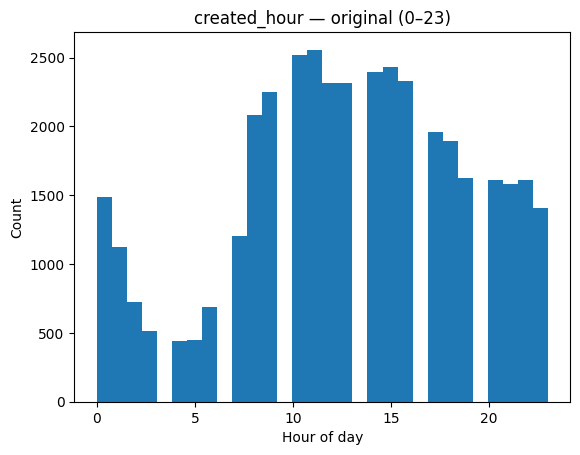

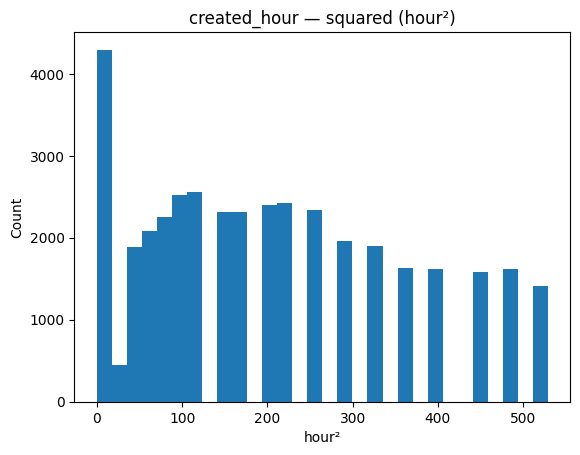

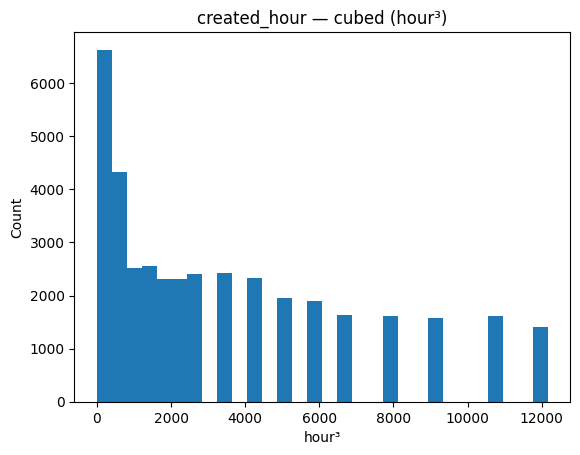

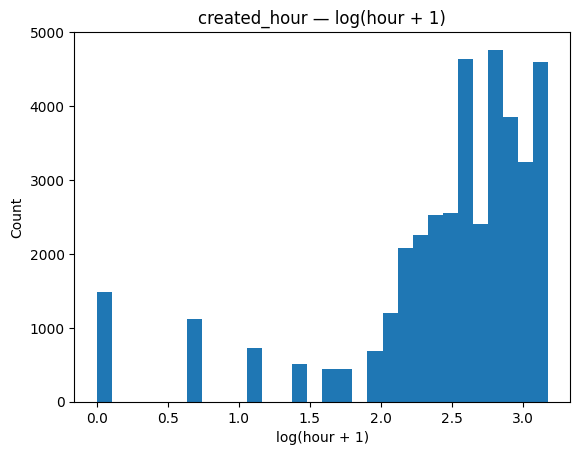

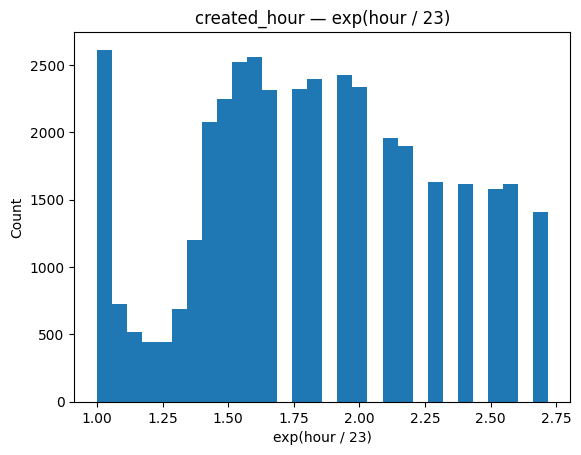

In [ ]:
# Feature 2: created_hour

nbins = 30

hr = df_train_clean['created_hour'].dropna().values
hr_norm = hr / 23.0

# original distribtion
plt.hist(hr, bins=nbins)
plt.title('created_hour — original (0–23)')
plt.xlabel('Hour of day')
plt.ylabel('Count')
plt.show()

# squared distribtion
plt.hist(hr ** 2, bins=nbins)
plt.title('created_hour — squared (hour²)')
plt.xlabel('hour²')
plt.ylabel('Count')
plt.show()

# cubed distribtion
plt.hist(hr ** 3, bins=nbins)
plt.title('created_hour — cubed (hour³)')
plt.xlabel('hour³')
plt.ylabel('Count')
plt.show()

# logarithmic distribtion
plt.hist(np.log(hr + 1), bins=nbins)
plt.title('created_hour — log(hour + 1)')
plt.xlabel('log(hour + 1)')
plt.ylabel('Count')
plt.show()

# exponential distribtion
plt.hist(np.exp(hr_norm), bins=nbins)
plt.title('created_hour — exp(hour / 23)')
plt.xlabel('exp(hour / 23)')
plt.ylabel('Count')
plt.show()

The scatter matrices show how each transformation compares to every other for both features.

For `response_time_hours`, the plots are curved rather than straight, each transformation changes the data in a different way. The most useful comparison is the original against the log version: the log pulls the extreme values closer to the rest.

For `created_hour`, the plots show dotted patterns instead of smooth ones because the feature only has 24 possible values, one for each hour of the day.

log works best for `response_time_hours`, and `created_hour` does not need any transformation.

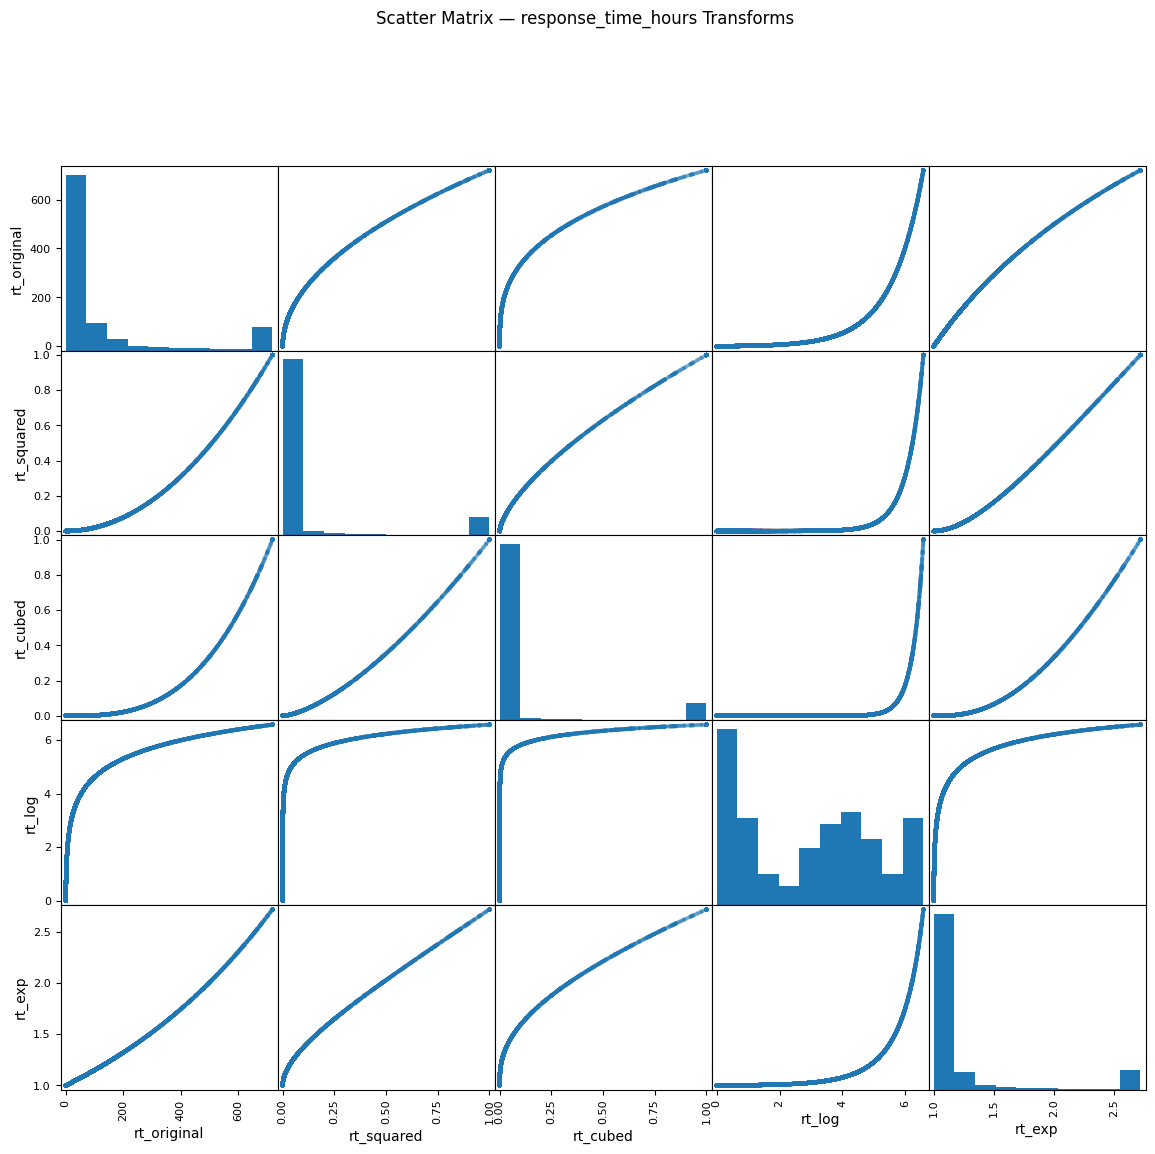

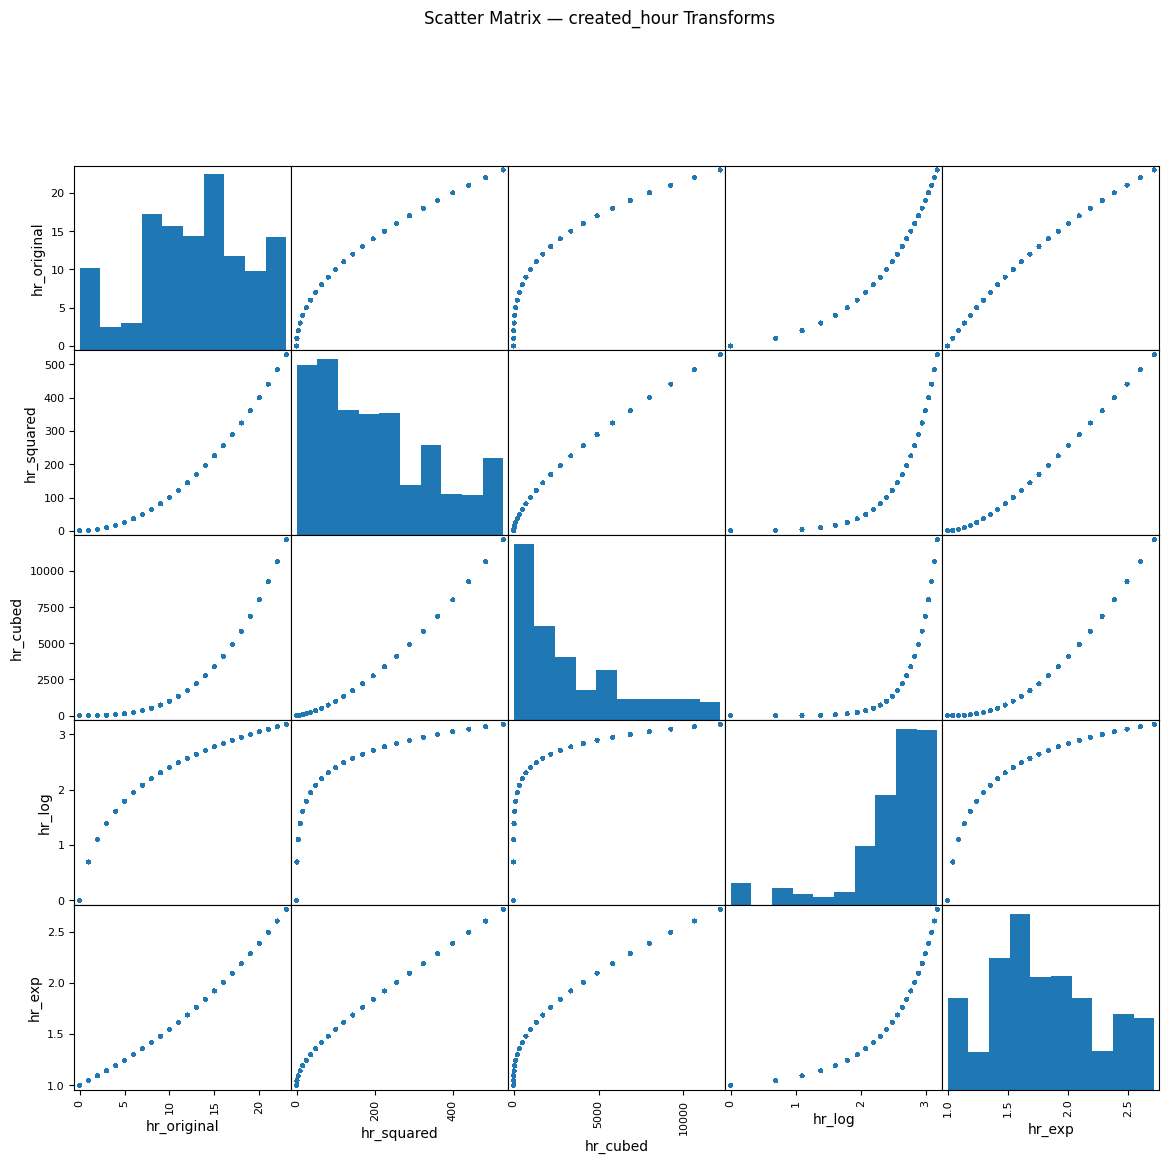

In [ ]:
# Scatter matrices of transformed data

rt_values = df_train_clean['response_time_hours'].clip(upper=720).dropna()
rt_norm_s = (rt_values - rt_values.min()) / (rt_values.max() - rt_values.min())

# DataFrame of all transforms for response_time_hours
transform_rt = pd.DataFrame({
    'rt_original': rt_values,
    'rt_squared': rt_norm_s ** 2,
    'rt_cubed': rt_norm_s ** 3,
    'rt_log': np.log(rt_values + 1),
    'rt_exp': np.exp(rt_norm_s),}).dropna()

scatter_matrix(transform_rt, figsize=(14, 12), diagonal='hist',
               alpha=0.2)
plt.suptitle('Scatter Matrix: response_time_hours Transforms', y=1.01)
plt.show()

# DataFrame of all transforms for created_hour
hr_values = df_train_clean['created_hour'].dropna()
hr_norm_s = hr_values / 23.0

transform_hr = pd.DataFrame({
    'hr_original': hr_values,
    'hr_squared': hr_values ** 2,
    'hr_cubed': hr_values ** 3,
    'hr_log': np.log(hr_values + 1),
    'hr_exp': np.exp(hr_norm_s),
}).dropna()

scatter_matrix(transform_hr, figsize=(14, 12), diagonal='hist',
               alpha=0.2)
plt.suptitle('Scatter Matrix: created_hour Transforms', y=1.01)
plt.show()